In [148]:
from games.mp import MP
from agents.regretmatching import RegretMatching
from agents.fictitiousplay import FictitiousPlay
from agents.random_agent import RandomAgent
from agents.iql import IndependentQLearning
from agents.jal_am import JointActionLearningAM
import matplotlib.pyplot as plt
import numpy as np

## Matching Pennies

Juego de **suma cero** con 2 agentes y 2 acciones: **H** (cara) y **T** (cruz).

Matrices de utilidades (filas = `agent_0`, columnas = `agent_1`):

|            | **H**     | **T**     |
|------------|-----------|-----------|
| **H**      | (+1, −1)  | (−1, +1)  |
| **T**      | (−1, +1)  | (+1, −1)  |

> Cada celda muestra `(u_0, u_1)`. Al ser un juego de suma cero, siempre `u_0 + u_1 = 0`.

**Estrategias dominantes puras:** ningún jugador tiene una estrategia que sea siempre mejor independientemente de lo que haga el oponente.
- `agent_0` prefiere **H** si `agent_1` juega H, pero prefiere **T** si `agent_1` juega T → no hay dominancia.
- `agent_1` prefiere **T** si `agent_0` juega H, pero prefiere **H** si `agent_0` juega T → no hay dominancia.


# Inicialización del juego


In [149]:
g = MP()

In [150]:
g.reset()

In [151]:
g.agents

['agent_0', 'agent_1']

## Funciones utilitarias

In [152]:
def play_game(game, agents, n_rounds=10000):
    """Reinicia el juego, ejecuta n_rounds rondas y retorna las políticas finales."""
    game.reset()
    for _ in range(n_rounds):
        actions = {a: agents[a].action() for a in game.agents}
        game.step(actions)
    return {a: agents[a].policy() for a in game.agents}


def track_convergence(game, agents, checkpoints):
    """Registra policy()[0] en cada checkpoint. Retorna dict de historiales."""
    game.reset()
    history = {a: [] for a in game.agents}
    step = 0
    for cp in checkpoints:
        for _ in range(cp - step):
            actions = {a: agents[a].action() for a in game.agents}
            game.step(actions)
        step = cp
        for a in game.agents:
            history[a].append(agents[a].policy()[0])
    return history


def plot_convergence(history, checkpoints, title, nash_eq=0.5, action_label='H'):
    """Grafica la convergencia de las políticas hacia el equilibrio de Nash."""
    fig, ax = plt.subplots(figsize=(8, 4))
    for agent, values in history.items():
        ax.plot(checkpoints, values, marker='o', label=agent)
    ax.axhline(nash_eq, color='gray', linestyle='--', label=f'Nash equilibrium ({nash_eq})')
    ax.set_xscale('log')
    ax.set_xlabel('Rondas (escala log)')
    ax.set_ylabel(f'P(jugar {action_label})')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## Experimentos: política final aprendida

### Regret Matching vs Regret Matching

In [153]:
agents = {a: RegretMatching(game=g, agent=a) for a in g.agents}
play_game(g, agents)

{'agent_0': array([0.49912405, 0.50087595]),
 'agent_1': array([0.50509048, 0.49490952])}

### Regret Matching vs Random Agent

In [154]:
agents = {'agent_0': RegretMatching(game=g, agent='agent_0'), 'agent_1': RandomAgent(game=g, agent='agent_1')}
play_game(g, agents)

{'agent_0': array([0.44534063, 0.55465937]), 'agent_1': array([0.5, 0.5])}

### Fictitious Play vs Fictitious Play

In [155]:
agents = {a: FictitiousPlay(game=g, agent=a) for a in g.agents}
play_game(g, agents)

{'agent_0': array([0.50704085, 0.49295915]),
 'agent_1': array([0.50034969, 0.49965031])}

### Fictitious Play vs Random Agent

In [156]:
agents = {'agent_0': FictitiousPlay(game=g, agent='agent_0'), 'agent_1': RandomAgent(game=g, agent='agent_1')}
play_game(g, agents)

{'agent_0': array([0.31897241, 0.68102759]), 'agent_1': array([0.5, 0.5])}

### IQL vs Random Agent

In [157]:
agents = {'agent_0': IndependentQLearning(game=g, agent='agent_0'), 'agent_1': RandomAgent(game=g, agent='agent_1')}
play_game(g, agents)

{'agent_0': array([0.37061763, 0.62938237]), 'agent_1': array([0.5, 0.5])}

### IQL vs IQL

In [158]:
agents = {a: IndependentQLearning(game=g, agent=a) for a in g.agents}
play_game(g, agents)

{'agent_0': array([0.36247395, 0.63752605]),
 'agent_1': array([0.88630443, 0.11369557])}

### IQL vs Joint Action Learning AM

In [159]:
agents = {'agent_0': IndependentQLearning(game=g, agent='agent_0'), 'agent_1': JointActionLearningAM(game=g, agent='agent_1')}
play_game(g, agents)

{'agent_0': array([0.10755133, 0.89244867]),
 'agent_1': array([0.50359438, 0.49640562])}

### Joint Action Learning AM vs Joint Action Learning AM

In [160]:
agents = {a: JointActionLearningAM(game=g, agent=a) for a in g.agents}
play_game(g, agents)

{'agent_0': array([0.04125012, 0.95874988]),
 'agent_1': array([0.45324462, 0.54675538])}

## Análisis de Convergencia hacia el Equilibrio de Nash

Se registra la probabilidad de jugar **H** de cada agente a lo largo del tiempo (checkpoints en escala log) para visualizar la convergencia al equilibrio de Nash **[0.5, 0.5]**.

In [161]:
checkpoints = [10, 50, 100, 500, 1000, 5000, 10000]

### Regret Matching vs Regret Matching

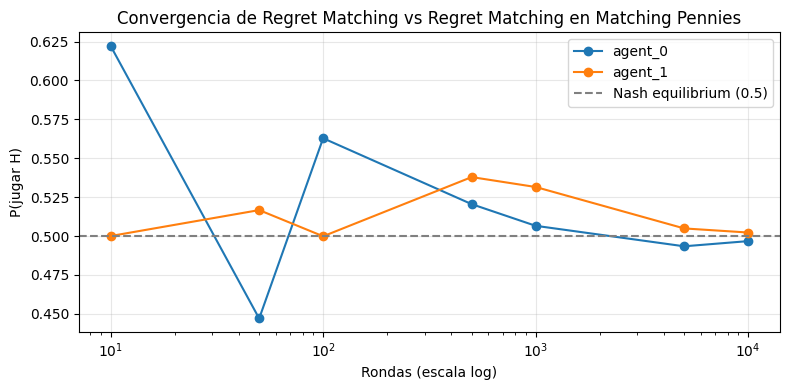

In [162]:
agents = {a: RegretMatching(game=g, agent=a) for a in g.agents}
history = track_convergence(g, agents, checkpoints)
plot_convergence(history, checkpoints, 'Convergencia de Regret Matching vs Regret Matching en Matching Pennies')

### Regret Matching vs Random Agent

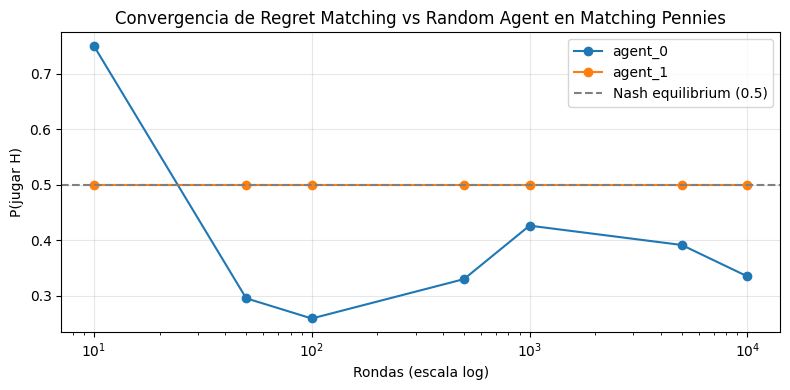

In [163]:
agents = {'agent_0': RegretMatching(game=g, agent='agent_0'), 'agent_1': RandomAgent(game=g, agent='agent_1')}
history = track_convergence(g, agents, checkpoints)
plot_convergence(history, checkpoints, 'Convergencia de Regret Matching vs Random Agent en Matching Pennies')

### Fictitious Play vs Fictitious Play

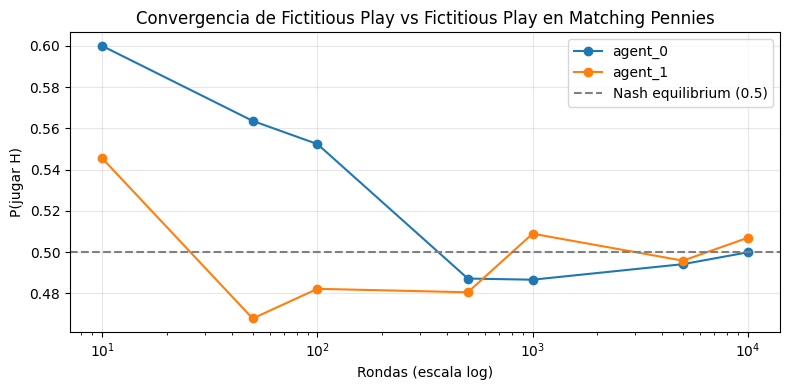

In [164]:
agents = {a: FictitiousPlay(game=g, agent=a) for a in g.agents}
history = track_convergence(g, agents, checkpoints)
plot_convergence(history, checkpoints, 'Convergencia de Fictitious Play vs Fictitious Play en Matching Pennies')

### Fictitious Play vs Random Agent

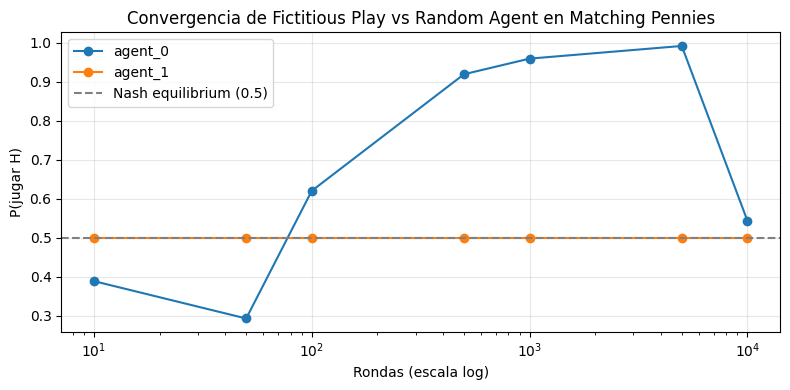

In [165]:
agents = {'agent_0': FictitiousPlay(game=g, agent='agent_0'), 'agent_1': RandomAgent(game=g, agent='agent_1')}
history = track_convergence(g, agents, checkpoints)
plot_convergence(history, checkpoints, 'Convergencia de Fictitious Play vs Random Agent en Matching Pennies')

### Fictitious Play vs Regret Matching

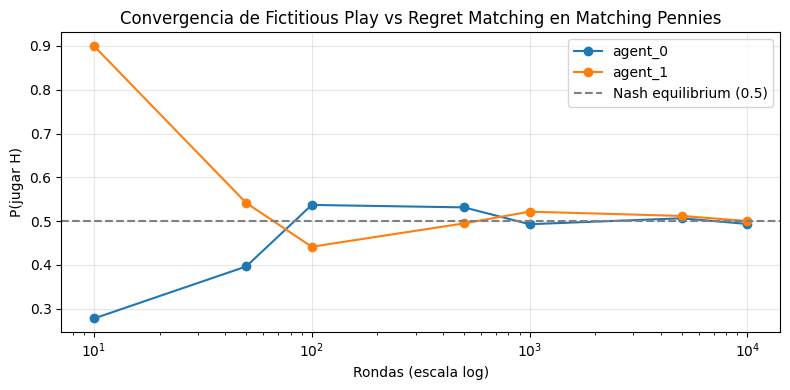

In [170]:
agents = {'agent_0': FictitiousPlay(game=g, agent='agent_0'), 'agent_1': RegretMatching(game=g, agent='agent_1')}
history = track_convergence(g, agents, checkpoints)
plot_convergence(history, checkpoints, 'Convergencia de Fictitious Play vs Regret Matching en Matching Pennies')

### IQL vs Random Agent

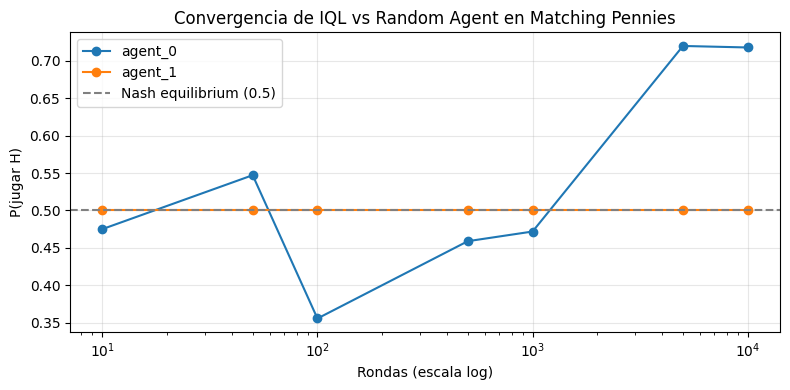

In [166]:
agents = {'agent_0': IndependentQLearning(game=g, agent='agent_0'), 'agent_1': RandomAgent(game=g, agent='agent_1')}
history = track_convergence(g, agents, checkpoints)
plot_convergence(history, checkpoints, 'Convergencia de IQL vs Random Agent en Matching Pennies')

### IQL vs IQL

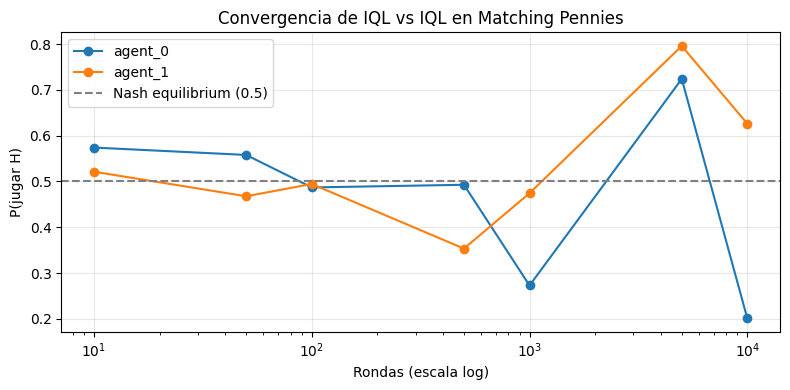

In [167]:
agents = {a: IndependentQLearning(game=g, agent=a) for a in g.agents}
history = track_convergence(g, agents, checkpoints)
plot_convergence(history, checkpoints, 'Convergencia de IQL vs IQL en Matching Pennies')

### IQL vs Joint Action Learning AM

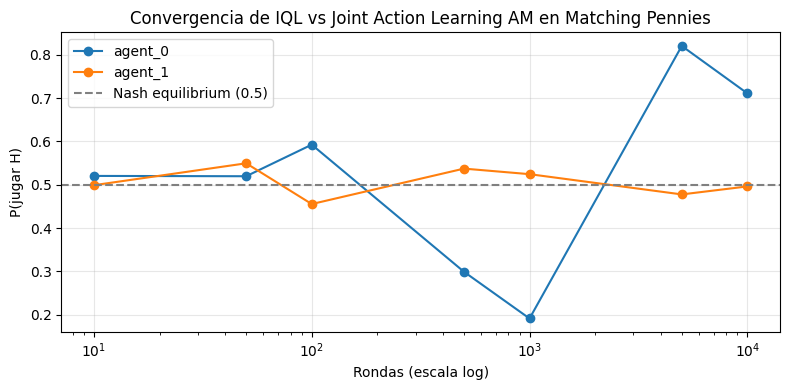

In [168]:
agents = {'agent_0': IndependentQLearning(game=g, agent='agent_0'), 'agent_1': JointActionLearningAM(game=g, agent='agent_1')}
history = track_convergence(g, agents, checkpoints)
plot_convergence(history, checkpoints, 'Convergencia de IQL vs Joint Action Learning AM en Matching Pennies')

### Joint Action Learning AM vs Joint Action Learning AM

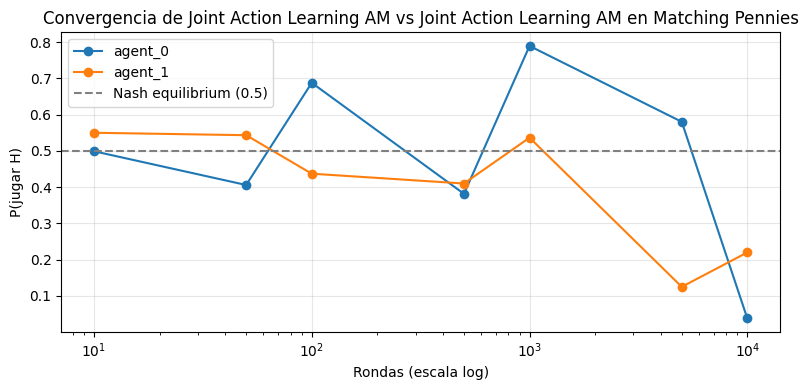

In [169]:
agents = {a: JointActionLearningAM(game=g, agent=a) for a in g.agents}
history = track_convergence(g, agents, checkpoints)
plot_convergence(history, checkpoints, 'Convergencia de Joint Action Learning AM vs Joint Action Learning AM en Matching Pennies')

## Conclusiones
- Como dijimos anteriormente, en Matching Pennies no hay estrategias dominantes puras(se desprende de la matriz de utilidades en la parte superior) y el equilibrio de Nash ocurre en estrategias mixtas(sorteando H y T con probabilidad *0.5*)
- De acuerdo con la performance obervada por cada agente en las partidas jugadas, podemos concluir comentando por cada agente:
    - **Random**: juega 50/50 y coincide con el equilibrio mixto, pero no aprende.
    - **IQL**: Fue el más inestable de todos, puede quedar sesgado al $\epsilon$ greedy en un problema que en principio no es estacionario.
    - **Ficticious Play**: En base a los experimentos, ha aproximado bien el equilibrio, es quizás el que mejor performó.
    - **Regret Matching**: Performó similar a Ficticious Play, aunque se desbió al final vs Random Agent, pero en promedio no estuvo tan lejos del equilibrio.
    - **JAL-AM**: Performa bastante mejor que IQL, ya que modela sus acciones y las del oponentes, aunque presentó mayores oscilaciones que Ficticious Play y Regret Matching.